# Simulasi VQE — Protein-Ligand Binding Energy
## Variational Quantum Eigensolver untuk Drug Discovery
**Sistem Model: N-Methylacetamide (NMA) ··· H₂O — Representasi Ikatan Hidrogen Protein-Ligand**

---

Notebook ini mengimplementasikan pipeline lengkap **VQE (Variational Quantum Eigensolver)**
untuk menghitung **binding energy** antara fragmen protein dan ligand.

Binding energy dihitung dari tiga kalkulasi VQE terpisah:
1. **E(protein)** → energi N-methylacetamide (representasi backbone protein)
2. **E(ligand)** → energi molekul air H₂O (representasi ligand kecil)
3. **E(complex)** → energi sistem terikat NMA···H₂O

Lalu: **ΔE_bind = E(complex) − E(protein) − E(ligand)**

Setiap sistem dijalankan dengan dua ansatz:
- **HEA** (Hardware Efficient Ansatz) → cepat, untuk validasi pipeline
- **UCCSD** (Unitary Coupled Cluster) → akurat secara kimia

Hasil VQE dibandingkan dengan **Exact FCI** (NumPy diagonalization) sebagai referensi.

> **Platform:** HPC / JupyterLab — CPU Simulator (StatevectorSimulator)

***1. Import Library***

In [1]:
import numpy as np
import time
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Qiskit core
from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorEstimator
from qiskit.circuit.library import EfficientSU2

# Qiskit Algorithms
from qiskit_algorithms import VQE, NumPyMinimumEigensolver
from qiskit_algorithms.optimizers import COBYLA, SPSA, L_BFGS_B

# Qiskit Nature — quantum chemistry
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.drivers.pyscfd.pyscfdriver import DistanceUnit
from qiskit_nature.second_q.mappers import JordanWignerMapper, BravyiKitaevMapper
from qiskit_nature.second_q.transformers import ActiveSpaceTransformer
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock

print('✅ Semua library berhasil diimport.')
print(f'   numpy           : {np.__version__}')

import qiskit
print(f'   qiskit          : {qiskit.__version__}')

import qiskit_nature
print(f'   qiskit-nature   : {qiskit_nature.__version__}')

import qiskit_algorithms
print(f'   qiskit-algorithms: {qiskit_algorithms.__version__}')

✅ Semua library berhasil diimport.
   numpy           : 2.2.6
   qiskit          : 2.3.0
   qiskit-nature   : 0.7.2
   qiskit-algorithms: 0.4.0


***2. Konfigurasi Parameter***

In [2]:
# ── Pilihan Active Space ──────────────────────────────────────────
# CAS(n_electrons, n_orbitals) → n_orbitals * 2 qubit (Jordan-Wigner)
#
# CAS_SMALL  : validasi cepat        → 4  qubit
# CAS_MEDIUM : riset standar         → 8  qubit
# CAS_LARGE  : akurasi tinggi (HPC)  → 16 qubit

CAS_SMALL  = (2, 2)    # 2 elektron, 2 orbital  → 4  qubit
CAS_MEDIUM = (4, 4)    # 4 elektron, 4 orbital  → 8  qubit
CAS_LARGE  = (6, 6)    # 6 elektron, 6 orbital  → 12 qubit

# ← Ganti sesuai resource yang tersedia
N_ELECTRONS, N_ORBITALS = CAS_MEDIUM

# ── Pilihan Ansatz ────────────────────────────────────────────────
# 'hea'   : Hardware Efficient Ansatz — cepat, untuk testing
# 'uccsd' : Unitary Coupled Cluster   — akurat, untuk riset
ANSATZ_TYPE = 'hea'

# ── Pilihan Mapper ────────────────────────────────────────────────
# 'jw' : Jordan-Wigner  (intuitif, qubit string panjang)
# 'bk' : Bravyi-Kitaev  (lebih efisien untuk sistem besar)
MAPPER_TYPE = 'jw'

# ── Optimizer ─────────────────────────────────────────────────────
# 'cobyla' : gradient-free, robust — rekomendasi awal
# 'spsa'   : stochastic gradient   — cocok untuk hardware nyata
# 'lbfgs'  : gradient-based        — cepat untuk simulasi bersih
OPTIMIZER   = 'cobyla'
MAX_ITER    = 300

# ── Basis Set ─────────────────────────────────────────────────────
# 'sto-3g'  : minimal, sangat cepat — untuk testing
# '6-31g'   : standar, lebih akurat
# 'cc-pvdz' : akurasi tinggi (butuh resource lebih besar)
BASIS_SET   = 'sto-3g'

# ── Flag ─────────────────────────────────────────────────────────
RUN_EXACT_REFERENCE = True    # hitung FCI referensi (butuh waktu ekstra)
RANDOM_SEED         = 42

# ── Ringkasan Konfigurasi ─────────────────────────────────────────
HARTREE_TO_KCAL = 627.509

print('=' * 52)
print('  KONFIGURASI VQE BINDING ENERGY')
print('=' * 52)
print(f'  Active space : CAS({N_ELECTRONS},{N_ORBITALS})')
print(f'  Qubit (est.) : {N_ORBITALS * 2} qubit (Jordan-Wigner)')
print(f'  Ansatz       : {ANSATZ_TYPE.upper()}')
print(f'  Mapper       : {"Jordan-Wigner" if MAPPER_TYPE=="jw" else "Bravyi-Kitaev"}')
print(f'  Optimizer    : {OPTIMIZER.upper()} (max {MAX_ITER} iter)')
print(f'  Basis set    : {BASIS_SET}')
print(f'  Referensi    : {"FCI (NumPy)" if RUN_EXACT_REFERENCE else "tidak dijalankan"}')
print('=' * 52)
print()

# Estimasi qubit per sistem
for label, cas in [('CAS_SMALL', CAS_SMALL), ('CAS_MEDIUM', CAS_MEDIUM), ('CAS_LARGE', CAS_LARGE)]:
    ne, no = cas
    qubit_jw = no * 2
    status = '← dipilih' if (ne, no) == (N_ELECTRONS, N_ORBITALS) else ''
    print(f'  {label}: CAS({ne},{no}) → {qubit_jw:2d} qubit (JW)  {status}')

  KONFIGURASI VQE BINDING ENERGY
  Active space : CAS(4,4)
  Qubit (est.) : 8 qubit (Jordan-Wigner)
  Ansatz       : HEA
  Mapper       : Jordan-Wigner
  Optimizer    : COBYLA (max 300 iter)
  Basis set    : sto-3g
  Referensi    : FCI (NumPy)

  CAS_SMALL: CAS(2,2) →  4 qubit (JW)  
  CAS_MEDIUM: CAS(4,4) →  8 qubit (JW)  ← dipilih
  CAS_LARGE: CAS(6,6) → 12 qubit (JW)  


***3. Definisi Fungsi***

In [12]:
# ── Geometri Molekul ──────────────────────────────────────────────
MOL_GEOMETRIES = {
    'protein_fragment': '''
        C   0.000   0.000   0.000
        O   0.000   0.000   1.220
        N   1.340   0.000  -0.370
        H   1.600   0.000  -1.330
        C   2.300   0.000   0.650
    ''',
    'ligand': '''
        O   0.000   0.000   0.000
        H   0.757   0.000   0.586
        H  -0.757   0.000   0.586
    ''',
    'complex': '''
        C   0.000   0.000   0.000
        O   0.000   0.000   1.220
        N   1.340   0.000  -0.370
        H   1.600   0.000  -1.330
        C   2.300   0.000   0.650
        O   0.000   0.150   3.100
        H   0.757   0.150   3.686
        H  -0.757   0.150   3.686
    ''',
}

MOL_LABELS = {
    'protein_fragment': 'Protein fragment (NMA)',
    'ligand'          : 'Ligand (H₂O)',
    'complex'         : 'Complex (NMA···H₂O)',
}


# ── build_hamiltonian() ───────────────────────────────────────────
def build_hamiltonian(mol_type, n_electrons, n_orbitals, mapper_type='jw', verbose=True):
    if verbose:
        print(f'  [1/4] Menjalankan Hartree-Fock (PySCF)...')

    driver = PySCFDriver(
        atom   = MOL_GEOMETRIES[mol_type].strip(),
        basis  = BASIS_SET,
        charge = 0, spin=0, unit=DistanceUnit.ANGSTROM
    )
    problem = driver.run()

    if verbose:
        print(f'  [2/4] Memotong ke active space CAS({n_electrons},{n_orbitals})...')

    transformer = ActiveSpaceTransformer(
        num_electrons        = n_electrons,     # ← FIX Bug 1
        num_spatial_orbitals = n_orbitals       # ← FIX Bug 1
    )
    as_problem = transformer.transform(problem)

    mapper_obj = JordanWignerMapper() if mapper_type == 'jw' else BravyiKitaevMapper()

    if verbose:
        print(f'  [3/4] Qubit mapping ({"JW" if mapper_type=="jw" else "BK"})...')

    qubit_op = mapper_obj.map(as_problem.hamiltonian.second_q_op())

    if verbose:
        print(f'  [4/4] Hamiltonian selesai.')
        print(f'        Qubit     : {qubit_op.num_qubits}')
        print(f'        Pauli term: {len(qubit_op)}')

    return (
        qubit_op,
        as_problem.num_particles,
        as_problem.num_spatial_orbitals,    # ← FIX Bug 2
        mapper_obj
    )


# ── build_ansatz() ────────────────────────────────────────────────
def build_ansatz(ansatz_type, num_qubits, num_particles, num_spatial_orbs, mapper_obj, verbose=True):
    if ansatz_type == 'uccsd':
        if verbose:
            print('  Ansatz: UCCSD + HF initial state')
        hf_state = HartreeFock(
            num_spatial_orbitals = num_spatial_orbs,    # ← FIX Bug 4
            num_particles        = num_particles,
            qubit_mapper         = mapper_obj
        )
        ansatz = UCCSD(
            num_spatial_orbitals = num_spatial_orbs,    # ← FIX Bug 4
            num_particles        = num_particles,
            qubit_mapper         = mapper_obj,
            initial_state        = hf_state
        )
    else:
        if verbose:
            print('  Ansatz: HEA (EfficientSU2, reps=2, linear entanglement)')
        ansatz = EfficientSU2(
            num_qubits      = num_qubits,
            reps            = 2,
            entanglement    = 'linear',
            insert_barriers = True
        )
    if verbose:
        print(f'  Parameter θ: {ansatz.num_parameters}')
    return ansatz


# ── run_vqe() ─────────────────────────────────────────────────────
def run_vqe(qubit_op, ansatz, optimizer_type='cobyla', max_iter=300, verbose=True):
    opts = {
        'cobyla': COBYLA(maxiter=max_iter),
        'spsa'  : SPSA(maxiter=max_iter),
        'lbfgs' : L_BFGS_B(maxiter=max_iter),
    }
    optimizer      = opts.get(optimizer_type, COBYLA(maxiter=max_iter))
    energy_history = []
    iter_count     = [0]

    # ✅ 4 argumen sesuai qiskit_algorithms 0.4.0
    def callback(eval_count, params, value, metadata):
        energy_history.append(float(value))
        iter_count[0] = eval_count
        if verbose and eval_count % 50 == 0:
            print(f'    iter {eval_count:4d} | E = {value:.8f} Ha')

    np.random.seed(RANDOM_SEED)
    init_pt = np.random.uniform(-0.1, 0.1, size=ansatz.num_parameters)

    vqe = VQE(
        estimator     = StatevectorEstimator(),
        ansatz        = ansatz,
        optimizer     = optimizer,
        callback      = callback,
        initial_point = init_pt
    )

    t0      = time.time()
    result  = vqe.compute_minimum_eigenvalue(operator=qubit_op)
    elapsed = time.time() - t0

    if verbose:
        print(f'  ✓ Konvergen dalam {elapsed:.1f}s | iter: {iter_count[0]}')
        print(f'  Energi VQE : {result.eigenvalue.real:.8f} Hartree')

    return {
        'energy'        : float(result.eigenvalue.real),
        'energy_history': energy_history,
        'num_evals'     : iter_count[0],
        'time'          : elapsed,
    }


# ── run_exact() ───────────────────────────────────────────────────
def run_exact(qubit_op, verbose=True):
    solver = NumPyMinimumEigensolver()
    result = solver.compute_minimum_eigenvalue(qubit_op)
    energy = float(result.eigenvalue.real)
    if verbose:
        print(f'  Energi exact (FCI): {energy:.8f} Hartree')
    return energy


print('✅ Semua fungsi siap.')

✅ Semua fungsi siap.


***4. Jalankan VQE — Tiga Sistem***

In [13]:
# Jalankan VQE untuk protein_fragment, ligand, dan complex
# Pipeline: build_hamiltonian → build_ansatz → run_exact → run_vqe

MOL_LIST = ['protein_fragment', 'ligand', 'complex']
results  = {}

for mol_type in MOL_LIST:
    label = MOL_LABELS[mol_type]
    print(f'\n{"─" * 56}')
    print(f'  Sistem: {label}')
    print(f'{"─" * 56}')

    # ── Build Hamiltonian ──────────────────────────────────────
    qubit_op, num_particles, num_spatial_orbs, mapper_obj = build_hamiltonian(
        mol_type, N_ELECTRONS, N_ORBITALS, MAPPER_TYPE, verbose=True
    )
    print()

    # ── Build Ansatz ───────────────────────────────────────────
    ansatz = build_ansatz(
        ANSATZ_TYPE, qubit_op.num_qubits,
        num_particles, num_spatial_orbs, mapper_obj, verbose=True
    )
    print()

    # ── Energi Exact (referensi FCI) ───────────────────────────
    energy_exact = None
    if RUN_EXACT_REFERENCE:
        energy_exact = run_exact(qubit_op, verbose=True)
    print()

    # ── Jalankan VQE ───────────────────────────────────────────
    print(f'  Menjalankan VQE ({OPTIMIZER.upper()}, max {MAX_ITER} iter)...')
    vqe_res = run_vqe(
        qubit_op, ansatz, OPTIMIZER, MAX_ITER, verbose=True
    )

    # ── Hitung error jika ada referensi ────────────────────────
    error_kcal = None
    if energy_exact is not None:
        error_kcal = abs(vqe_res['energy'] - energy_exact) * HARTREE_TO_KCAL
        status = '✓ chemical accuracy' if error_kcal < 1.0 else '✗ belum chemical accuracy'
        print(f'  Error vs FCI: {error_kcal:.4f} kcal/mol  [{status}]')

    results[mol_type] = {
        'label'         : label,
        'vqe'           : vqe_res['energy'],
        'exact'         : energy_exact,
        'error_kcal'    : error_kcal,
        'energy_history': vqe_res['energy_history'],
        'num_evals'     : vqe_res['num_evals'],
        'time'          : vqe_res['time'],
        'num_qubits'    : qubit_op.num_qubits,
        'num_params'    : ansatz.num_parameters,
    }

print(f'\n{"=" * 56}')
print('  Semua sistem selesai dijalankan.')
print(f'{"=" * 56}')


────────────────────────────────────────────────────────
  Sistem: Protein fragment (NMA)
────────────────────────────────────────────────────────
  [1/4] Menjalankan Hartree-Fock (PySCF)...
  [2/4] Memotong ke active space CAS(4,4)...
  [3/4] Qubit mapping (JW)...
  [4/4] Hamiltonian selesai.
        Qubit     : 8
        Pauli term: 185

  Ansatz: HEA (EfficientSU2, reps=2, linear entanglement)
  Parameter θ: 48

  Energi exact (FCI): -3.75122536 Hartree

  Menjalankan VQE (COBYLA, max 300 iter)...
    iter   50 | E = -3.00651407 Ha
    iter  100 | E = -3.46554337 Ha
    iter  150 | E = -3.57037310 Ha
    iter  200 | E = -3.60736499 Ha
    iter  250 | E = -3.64963865 Ha
    iter  300 | E = -3.66676599 Ha
  ✓ Konvergen dalam 9.6s | iter: 300
  Energi VQE : -3.66931359 Hartree
  Error vs FCI: 51.4004 kcal/mol  [✗ belum chemical accuracy]

────────────────────────────────────────────────────────
  Sistem: Ligand (H₂O)
────────────────────────────────────────────────────────
  [1/4] Men

***5. Hitung Binding Energy***

In [14]:
# ── Kalkulasi Binding Energy ──────────────────────────────────────
# ΔE_bind = E(complex) − E(protein_fragment) − E(ligand)

E_protein = results['protein_fragment']['vqe']
E_ligand  = results['ligand']['vqe']
E_complex = results['complex']['vqe']

dE_vqe_ha   = E_complex - E_protein - E_ligand
dE_vqe_kcal = dE_vqe_ha * HARTREE_TO_KCAL

dE_exact_ha   = None
dE_exact_kcal = None
if RUN_EXACT_REFERENCE and all(results[m]['exact'] is not None for m in MOL_LIST):
    dE_exact_ha   = (results['complex']['exact']
                   - results['protein_fragment']['exact']
                   - results['ligand']['exact'])
    dE_exact_kcal = dE_exact_ha * HARTREE_TO_KCAL

# ── Simpan ke results untuk plot ─────────────────────────────────
results['binding'] = {
    'vqe_ha'   : dE_vqe_ha,
    'vqe_kcal' : dE_vqe_kcal,
    'exact_ha' : dE_exact_ha,
    'exact_kcal': dE_exact_kcal,
}

# ── Tabel Hasil ───────────────────────────────────────────────────
print('=' * 62)
print('  TABEL HASIL VQE — BINDING ENERGY NMA···H₂O')
print('=' * 62)
print(f'  Active space : CAS({N_ELECTRONS},{N_ORBITALS})')
print(f'  Ansatz       : {ANSATZ_TYPE.upper()}')
print(f'  Basis set    : {BASIS_SET}')
print()
print(f'  {"Sistem":<30} {"E_VQE (Ha)":>14} {"E_exact (Ha)":>14} {"Error (kcal)":>12}')
print('  ' + '─' * 72)

for mol_type in MOL_LIST:
    r    = results[mol_type]
    e_ex = f"{r['exact']:.8f}" if r['exact'] is not None else 'n/a'
    e_er = f"{r['error_kcal']:.4f}" if r['error_kcal'] is not None else 'n/a'
    chk  = ('✓' if r['error_kcal'] is not None and r['error_kcal'] < 1.0
            else '✗' if r['error_kcal'] is not None else '')
    print(f"  {r['label']:<30} {r['vqe']:>14.8f} {e_ex:>14} {e_er:>10} {chk}")

print('  ' + '─' * 72)
print()
print(f'  ΔE_bind (VQE)  = {dE_vqe_ha:>14.8f} Ha')
print(f'               = {dE_vqe_kcal:>12.4f} kcal/mol')

if dE_exact_ha is not None:
    err_be_kcal = abs(dE_vqe_kcal - dE_exact_kcal)
    print(f'  ΔE_bind (FCI)  = {dE_exact_ha:>14.8f} Ha')
    print(f'               = {dE_exact_kcal:>12.4f} kcal/mol')
    print(f'  Error ΔE_bind  = {err_be_kcal:>12.4f} kcal/mol')
    status_be = '✓ chemical accuracy (<1 kcal/mol)' if err_be_kcal < 1.0 else '✗ belum chemical accuracy'
    print(f'  Status         : {status_be}')

print()
print('  Interpretasi binding energy:')
if dE_vqe_kcal < 0:
    print(f'  → ΔE = {dE_vqe_kcal:.2f} kcal/mol (negatif) → ikatan STABIL ✓')
    if abs(dE_vqe_kcal) < 1:
        print('  → Kekuatan: < 1 kcal/mol → van der Waals')
    elif abs(dE_vqe_kcal) < 5:
        print('  → Kekuatan: 1–5 kcal/mol → ikatan hidrogen tipikal')
    else:
        print('  → Kekuatan: > 5 kcal/mol → interaksi elektrostatik kuat')
else:
    print(f'  → ΔE = {dE_vqe_kcal:.2f} kcal/mol (positif) → ikatan TIDAK STABIL')

print()
print('=' * 62)
print('  RINGKASAN KOMPUTASI')
print('=' * 62)
print(f'  {"Sistem":<30} {"Qubit":>6} {"Param":>6} {"Iter":>6} {"Waktu (s)":>10}')
print('  ' + '─' * 62)
for mol_type in MOL_LIST:
    r = results[mol_type]
    print(f"  {r['label']:<30} {r['num_qubits']:>6} {r['num_params']:>6} "
          f"{r['num_evals']:>6} {r['time']:>10.1f}")
total_t = sum(results[m]['time'] for m in MOL_LIST)
print('  ' + '─' * 62)
print(f'  {"Total":<30} {"": >6} {"": >6} {"": >6} {total_t:>10.1f}')

  TABEL HASIL VQE — BINDING ENERGY NMA···H₂O
  Active space : CAS(4,4)
  Ansatz       : HEA
  Basis set    : sto-3g

  Sistem                             E_VQE (Ha)   E_exact (Ha) Error (kcal)
  ────────────────────────────────────────────────────────────────────────
  Protein fragment (NMA)            -3.66931359    -3.75122536    51.4004 ✗
  Ligand (H₂O)                      -5.61701827    -6.16315681   342.7068 ✗
  Complex (NMA···H₂O)               -3.24088020    -3.38745648    91.9779 ✗
  ────────────────────────────────────────────────────────────────────────

  ΔE_bind (VQE)  =     6.04545166 Ha
               =    3793.5753 kcal/mol
  ΔE_bind (FCI)  =     6.52692569 Ha
               =    4095.7046 kcal/mol
  Error ΔE_bind  =     302.1293 kcal/mol
  Status         : ✗ belum chemical accuracy

  Interpretasi binding energy:
  → ΔE = 3793.58 kcal/mol (positif) → ikatan TIDAK STABIL

  RINGKASAN KOMPUTASI
  Sistem                          Qubit  Param   Iter  Waktu (s)
  ──────────

***6. Plot Konvergensi VQE — Tiga Sistem***

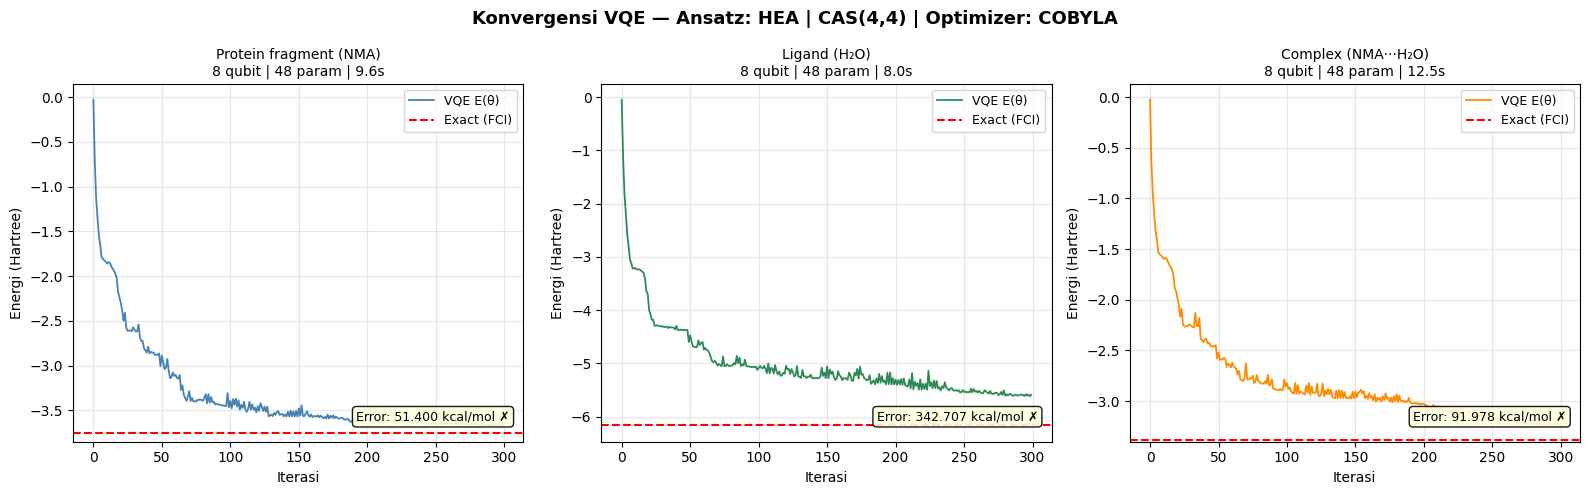

Gambar disimpan: vqe_convergence.png


In [15]:
# Plot konvergensi energi VQE per iterasi vs energi exact (FCI)
# Tiga panel horizontal — satu per sistem molekul

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    f'Konvergensi VQE — Ansatz: {ANSATZ_TYPE.upper()} | '
    f'CAS({N_ELECTRONS},{N_ORBITALS}) | Optimizer: {OPTIMIZER.upper()}',
    fontsize=13, fontweight='bold'
)

COLORS = {'protein_fragment': 'steelblue', 'ligand': 'seagreen', 'complex': 'darkorange'}

for ax, mol_type in zip(axes, MOL_LIST):
    r       = results[mol_type]
    history = r['energy_history']
    iters   = range(len(history))
    color   = COLORS[mol_type]

    # ── Kurva VQE ────────────────────────────────────────────
    ax.plot(iters, history, color=color, linewidth=1.3,
            label=f'VQE E(θ)', zorder=3)

    # ── Garis exact FCI ──────────────────────────────────────
    if r['exact'] is not None:
        ax.axhline(r['exact'], color='red', linestyle='--',
                   linewidth=1.5, label='Exact (FCI)', zorder=2)

    # ── Anotasi error akhir ───────────────────────────────────
    if r['error_kcal'] is not None:
        chk = '✓' if r['error_kcal'] < 1.0 else '✗'
        ax.text(
            0.97, 0.06,
            f'Error: {r["error_kcal"]:.3f} kcal/mol {chk}',
            transform=ax.transAxes, ha='right', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9)
        )

    ax.set_title(f'{r["label"]}\n{r["num_qubits"]} qubit | {r["num_params"]} param | {r["time"]:.1f}s',
                 fontsize=10)
    ax.set_xlabel('Iterasi', fontsize=10)
    ax.set_ylabel('Energi (Hartree)', fontsize=10)
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('vqe_convergence.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gambar disimpan: vqe_convergence.png')

***7. Plot Error Konvergensi (Log Scale)***

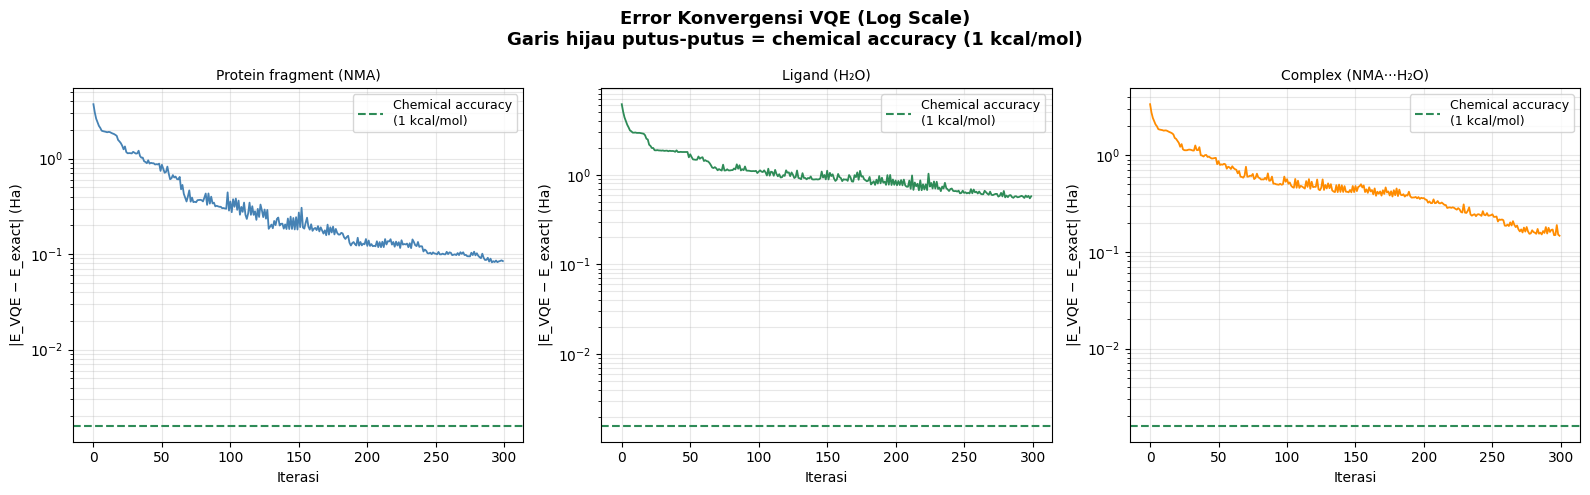

Gambar disimpan: vqe_error_logscale.png


In [16]:
# Log-scale error |E_VQE - E_exact| per iterasi
# Garis putus-putus hijau = batas chemical accuracy (1 kcal/mol = 1.6e-3 Hartree)

if not RUN_EXACT_REFERENCE:
    print('RUN_EXACT_REFERENCE = False, plot ini dilewati.')
else:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(
        'Error Konvergensi VQE (Log Scale)\n'
        'Garis hijau putus-putus = chemical accuracy (1 kcal/mol)',
        fontsize=13, fontweight='bold'
    )

    CHEM_ACC_HA = 1.0 / HARTREE_TO_KCAL    # 1 kcal/mol dalam Hartree

    for ax, mol_type in zip(axes, MOL_LIST):
        r       = results[mol_type]
        if r['exact'] is None:
            ax.set_visible(False)
            continue

        errors  = [max(abs(e - r['exact']), 1e-12) for e in r['energy_history']]
        iters   = range(len(errors))
        color   = COLORS[mol_type]

        ax.semilogy(iters, errors, color=color, linewidth=1.3)
        ax.axhline(CHEM_ACC_HA, color='seagreen', linestyle='--',
                   linewidth=1.5, label='Chemical accuracy\n(1 kcal/mol)')

        # Tandai iterasi pertama yang capai chemical accuracy
        for i, err in enumerate(errors):
            if err <= CHEM_ACC_HA:
                ax.axvline(i, color='gray', linestyle=':', linewidth=1, alpha=0.7)
                ax.text(i + 2, CHEM_ACC_HA * 2,
                        f'iter {i}', fontsize=8, color='gray')
                break

        ax.set_title(f'{r["label"]}', fontsize=10)
        ax.set_xlabel('Iterasi', fontsize=10)
        ax.set_ylabel('|E_VQE − E_exact| (Ha)', fontsize=10)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3, which='both')

    plt.tight_layout()
    plt.savefig('vqe_error_logscale.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Gambar disimpan: vqe_error_logscale.png')

***8. Plot Binding Energy Summary***

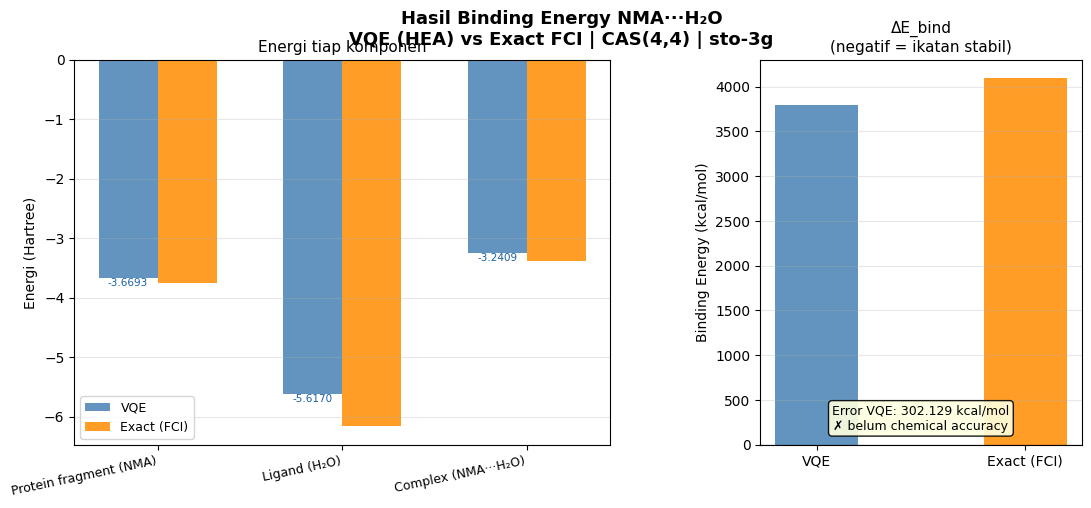

Gambar disimpan: vqe_binding_energy.png


In [17]:
# Visualisasi binding energy — dua panel:
# Kiri  : energi tiap komponen (VQE vs FCI)
# Kanan : ΔE_bind dalam kcal/mol dengan label interpretasi

fig = plt.figure(figsize=(13, 5))
fig.suptitle(
    'Hasil Binding Energy NMA···H₂O\n'
    f'VQE ({ANSATZ_TYPE.upper()}) vs Exact FCI | CAS({N_ELECTRONS},{N_ORBITALS}) | {BASIS_SET}',
    fontsize=13, fontweight='bold'
)
gs = gridspec.GridSpec(1, 2, figure=fig, width_ratios=[2, 1.2], wspace=0.35)

# ── Panel kiri: energi komponen ──────────────────────────────────
ax1    = fig.add_subplot(gs[0])
labels = [r['label'] for r in [results['protein_fragment'],
                                 results['ligand'],
                                 results['complex']]]
e_vqe  = [results[m]['vqe']   for m in MOL_LIST]
e_exact= [results[m]['exact'] for m in MOL_LIST]

x = np.arange(len(labels))
w = 0.32
bars1 = ax1.bar(x - w/2, e_vqe,   w, label='VQE',   color='steelblue',  alpha=0.85)
if all(e is not None for e in e_exact):
    bars2 = ax1.bar(x + w/2, e_exact, w, label='Exact (FCI)', color='darkorange', alpha=0.85)

ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontsize=9, rotation=12, ha='right')
ax1.set_ylabel('Energi (Hartree)', fontsize=10)
ax1.set_title('Energi tiap komponen', fontsize=11)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3, axis='y')

for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() * (1.0005 if bar.get_height() < 0 else 0.9995),
             f'{bar.get_height():.4f}',
             ha='center', va='top', fontsize=7.5, color='#185FA5')

# ── Panel kanan: ΔE_bind ─────────────────────────────────────────
ax2 = fig.add_subplot(gs[1])
b   = results['binding']

be_vals   = [b['vqe_kcal']]
be_labels = ['VQE']
be_colors = ['steelblue']

if b['exact_kcal'] is not None:
    be_vals.append(b['exact_kcal'])
    be_labels.append('Exact (FCI)')
    be_colors.append('darkorange')

bars = ax2.bar(be_labels, be_vals, color=be_colors, alpha=0.85, width=0.4)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_ylabel('Binding Energy (kcal/mol)', fontsize=10)
ax2.set_title('ΔE_bind\n(negatif = ikatan stabil)', fontsize=11)
ax2.grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, be_vals):
    va  = 'top'    if val < 0 else 'bottom'
    yp  = val - 0.05 if val < 0 else val + 0.05
    ax2.text(bar.get_x() + bar.get_width()/2, yp,
             f'{val:.2f}\nkcal/mol',
             ha='center', va=va, fontsize=10,
             fontweight='bold', color='white')

# Keterangan error
if b['exact_kcal'] is not None:
    err = abs(b['vqe_kcal'] - b['exact_kcal'])
    chk = '✓ chemical accuracy' if err < 1.0 else '✗ belum chemical accuracy'
    ax2.text(0.5, 0.04,
             f'Error VQE: {err:.3f} kcal/mol\n{chk}',
             transform=ax2.transAxes, ha='center', fontsize=9,
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))

plt.savefig('vqe_binding_energy.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gambar disimpan: vqe_binding_energy.png')

***9. Eksperimen — Active Space Scan***

  EKSPERIMEN: Active Space Scan — Ligand H₂O
     CAS      Qubit     E_VQE (Ha)      E_exact (Ha)   Error (kcal)  Waktu (s) 
  ────────────────────────────────────────────────────────────────────────────
  CAS(2,2)      4         -1.66178142      -1.66389343      1.3253 ✗        2.4
  CAS(4,4)      8         -5.39554972      -6.16315681    481.6804 ✗        5.4
  CAS(6,6)   GAGAL: 'More orbitals requested than available.'
  ────────────────────────────────────────────────────────────────────────────



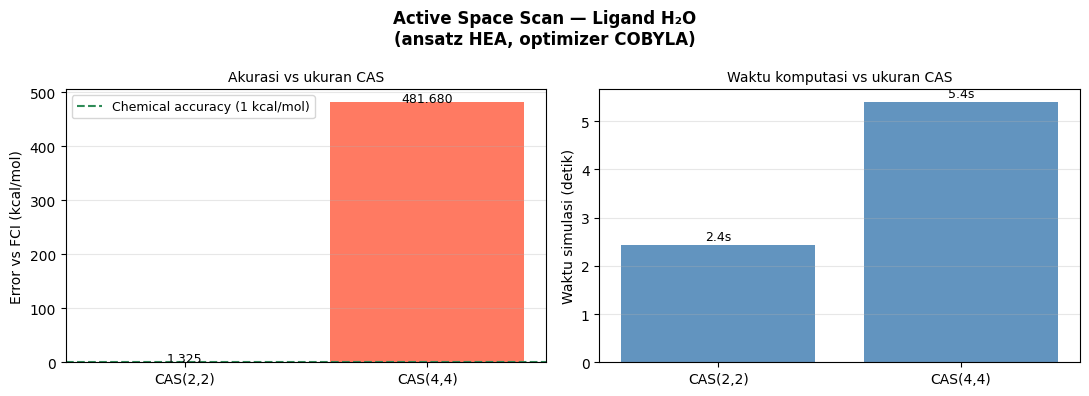

Gambar disimpan: active_space_scan.png


In [18]:
# Scan ukuran active space pada ligand (H2O) — sistem terkecil
# Tujuan: lihat bagaimana akurasi dan waktu berubah seiring CAS yang membesar

print('=' * 62)
print('  EKSPERIMEN: Active Space Scan — Ligand H₂O')
print('=' * 62)
print(f'  {"CAS":^10} {"Qubit":^7} {"E_VQE (Ha)":^16} '
      f'{"E_exact (Ha)":^16} {"Error (kcal)":^13} {"Waktu (s)":^10}')
print('  ' + '─' * 76)

scan_results = []

for ne, no in [(2, 2), (4, 4), (6, 6)]:
    try:
        qubit_op, num_p, num_so, mapper_obj = build_hamiltonian(
            'ligand', ne, no, MAPPER_TYPE, verbose=False
        )
        e_ex  = run_exact(qubit_op, verbose=False)
        anst  = build_ansatz('hea', qubit_op.num_qubits, num_p, num_so,
                              mapper_obj, verbose=False)
        res   = run_vqe(qubit_op, anst, 'cobyla', 200, verbose=False)
        err   = abs(res['energy'] - e_ex) * HARTREE_TO_KCAL
        chk   = '✓' if err < 1.0 else '✗'
        print(f'  CAS({ne},{no})   {qubit_op.num_qubits:^7} '
              f'{res["energy"]:>16.8f} {e_ex:>16.8f} '
              f'{err:>11.4f} {chk}  {res["time"]:>9.1f}')
        scan_results.append({
            'cas': f'CAS({ne},{no})', 'qubit': qubit_op.num_qubits,
            'error_kcal': err, 'time': res['time']
        })
    except Exception as exc:
        print(f'  CAS({ne},{no})   GAGAL: {exc}')

print('  ' + '─' * 76)
print()

# ── Plot Active Space Scan ────────────────────────────────────────
if scan_results:
    fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 4))
    fig.suptitle('Active Space Scan — Ligand H₂O\n(ansatz HEA, optimizer COBYLA)',
                 fontsize=12, fontweight='bold')

    cas_labels = [r['cas'] for r in scan_results]
    errors     = [r['error_kcal'] for r in scan_results]
    times      = [r['time']       for r in scan_results]

    bar_colors = ['seagreen' if e < 1.0 else 'tomato' for e in errors]

    axL.bar(cas_labels, errors, color=bar_colors, alpha=0.85)
    axL.axhline(1.0, color='seagreen', linestyle='--', linewidth=1.5,
                label='Chemical accuracy (1 kcal/mol)')
    axL.set_ylabel('Error vs FCI (kcal/mol)', fontsize=10)
    axL.set_title('Akurasi vs ukuran CAS', fontsize=10)
    axL.legend(fontsize=9)
    axL.grid(True, alpha=0.3, axis='y')
    for i, (label, val) in enumerate(zip(cas_labels, errors)):
        axL.text(i, val + 0.01, f'{val:.3f}', ha='center', fontsize=9)

    axR.bar(cas_labels, times, color='steelblue', alpha=0.85)
    axR.set_ylabel('Waktu simulasi (detik)', fontsize=10)
    axR.set_title('Waktu komputasi vs ukuran CAS', fontsize=10)
    axR.grid(True, alpha=0.3, axis='y')
    for i, (label, val) in enumerate(zip(cas_labels, times)):
        axR.text(i, val + 0.1, f'{val:.1f}s', ha='center', fontsize=9)

    plt.tight_layout()
    plt.savefig('active_space_scan.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Gambar disimpan: active_space_scan.png')

***10. Eksperimen — Perbandingan Ansatz (HEA vs UCCSD)***

  EKSPERIMEN: HEA vs UCCSD — Ligand H₂O CAS(2,2)
  Energi exact (FCI): -1.66389343 Hartree

  ── Ansatz: HEA ──
  Ansatz: HEA (EfficientSU2, reps=2, linear entanglement)
  Parameter θ: 24
    iter   50 | E = -1.53950426 Ha
    iter  100 | E = -1.63199996 Ha
    iter  150 | E = -1.65818993 Ha
    iter  200 | E = -1.66178142 Ha
    iter  250 | E = -1.66209075 Ha
    iter  300 | E = -1.66226361 Ha
  ✓ Konvergen dalam 3.6s | iter: 300
  Energi VQE : -1.66228862 Hartree
  Error  : 1.0070 kcal/mol  [✗]

  ── Ansatz: UCCSD ──
  Ansatz: UCCSD + HF initial state
  Parameter θ: 3
    iter   50 | E = -1.66389342 Ha
  ✓ Konvergen dalam 3.0s | iter: 52
  Energi VQE : -1.66389342 Hartree
  Error  : 0.0000 kcal/mol  [✓]



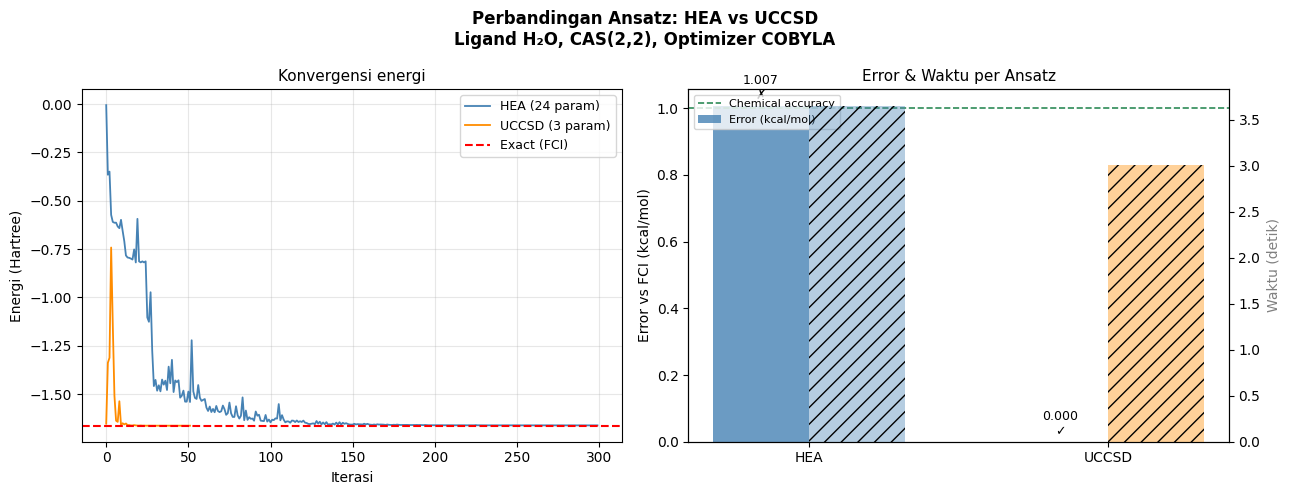

Gambar disimpan: ansatz_comparison.png


In [19]:
# Bandingkan HEA vs UCCSD pada ligand H2O CAS(2,2)
# Metrik: akurasi (error vs FCI) dan waktu komputasi

print('=' * 62)
print('  EKSPERIMEN: HEA vs UCCSD — Ligand H₂O CAS(2,2)')
print('=' * 62)

qubit_op_cmp, num_p_cmp, num_so_cmp, mapper_cmp = build_hamiltonian(
    'ligand', 2, 2, MAPPER_TYPE, verbose=False
)
e_ref = run_exact(qubit_op_cmp, verbose=False)
print(f'  Energi exact (FCI): {e_ref:.8f} Hartree\n')

ansatz_results = {}
for atype in ['hea', 'uccsd']:
    print(f'  ── Ansatz: {atype.upper()} ──')
    anst = build_ansatz(atype, qubit_op_cmp.num_qubits, num_p_cmp,
                        num_so_cmp, mapper_cmp, verbose=True)
    res  = run_vqe(qubit_op_cmp, anst, 'cobyla', 300, verbose=True)
    err  = abs(res['energy'] - e_ref) * HARTREE_TO_KCAL
    chk  = '✓' if err < 1.0 else '✗'
    print(f'  Error  : {err:.4f} kcal/mol  [{chk}]')
    print()
    ansatz_results[atype] = {'res': res, 'err': err, 'n_params': anst.num_parameters}

# ── Plot perbandingan konvergensi ─────────────────────────────────
fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Perbandingan Ansatz: HEA vs UCCSD\nLigand H₂O, CAS(2,2), Optimizer COBYLA',
             fontsize=12, fontweight='bold')

for atype, color in [('hea', 'steelblue'), ('uccsd', 'darkorange')]:
    ar      = ansatz_results[atype]
    history = ar['res']['energy_history']
    axL.plot(range(len(history)), history, color=color, linewidth=1.3,
             label=f'{atype.upper()} ({ar["n_params"]} param)')

axL.axhline(e_ref, color='red', linestyle='--', linewidth=1.5, label='Exact (FCI)')
axL.set_xlabel('Iterasi', fontsize=10)
axL.set_ylabel('Energi (Hartree)', fontsize=10)
axL.set_title('Konvergensi energi', fontsize=11)
axL.legend(fontsize=9)
axL.grid(True, alpha=0.3)

# Bar: error dan waktu
cats   = ['HEA', 'UCCSD']
errors = [ansatz_results['hea']['err'], ansatz_results['uccsd']['err']]
times  = [ansatz_results['hea']['res']['time'], ansatz_results['uccsd']['res']['time']]

x2 = np.arange(len(cats))
w2 = 0.32
ax2a = axR
ax2b = axR.twinx()

b1 = ax2a.bar(x2 - w2/2, errors, w2, color=['steelblue', 'darkorange'], alpha=0.8,
              label='Error (kcal/mol)')
b2 = ax2b.bar(x2 + w2/2, times,  w2, color=['steelblue', 'darkorange'], alpha=0.4,
              hatch='//', label='Waktu (s)')

ax2a.axhline(1.0, color='seagreen', linestyle='--', linewidth=1.2,
             label='Chemical accuracy')
ax2a.set_xticks(x2); ax2a.set_xticklabels(cats)
ax2a.set_ylabel('Error vs FCI (kcal/mol)', fontsize=10)
ax2b.set_ylabel('Waktu (detik)', fontsize=10, color='gray')
ax2a.set_title('Error & Waktu per Ansatz', fontsize=11)
ax2a.legend(loc='upper left', fontsize=8)

for bar, val in zip(b1, errors):
    chk = '✓' if val < 1.0 else '✗'
    ax2a.text(bar.get_x() + bar.get_width()/2, val + 0.02,
              f'{val:.3f}\n{chk}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('ansatz_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gambar disimpan: ansatz_comparison.png')

***11. Info Node***

In [20]:
import socket, sys, os
import qiskit, qiskit_nature, qiskit_algorithms

print('=' * 52)
print('  INFO NODE & ENVIRONMENT')
print('=' * 52)
print(f'  Hostname          : {socket.gethostname()}')
print(f'  Python            : {sys.version.split()[0]}')
print(f'  Executable        : {sys.executable}')
print(f'  CPU cores         : {os.cpu_count()}')
print()
print(f'  qiskit            : {qiskit.__version__}')
print(f'  qiskit-nature     : {qiskit_nature.__version__}')
print(f'  qiskit-algorithms : {qiskit_algorithms.__version__}')
print(f'  numpy             : {np.__version__}')
print()
print(f'  Konfigurasi run:')
print(f'  Active space      : CAS({N_ELECTRONS},{N_ORBITALS})')
print(f'  Ansatz            : {ANSATZ_TYPE.upper()}')
print(f'  Mapper            : {MAPPER_TYPE.upper()}')
print(f'  Optimizer         : {OPTIMIZER.upper()} (max {MAX_ITER} iter)')
print(f'  Basis set         : {BASIS_SET}')
print()
print('  File output:')
for fname in sorted(os.listdir('.')):
    if fname.endswith('.png'):
        size_kb = os.path.getsize(fname) // 1024
        print(f'  📊 {fname} ({size_kb} KB)')

  INFO NODE & ENVIRONMENT
  Hostname          : trembesi91
  Python            : 3.10.19
  Executable        : /mgpfs/home/mkhairiansyah/.conda/envs/env-ml/bin/python
  CPU cores         : 128

  qiskit            : 2.3.0
  qiskit-nature     : 0.7.2
  qiskit-algorithms : 0.4.0
  numpy             : 2.2.6

  Konfigurasi run:
  Active space      : CAS(4,4)
  Ansatz            : HEA
  Mapper            : JW
  Optimizer         : COBYLA (max 300 iter)
  Basis set         : sto-3g

  File output:
  📊 active_space_scan.png (63 KB)
  📊 ansatz_comparison.png (120 KB)
  📊 comparison_multi_N.png (141 KB)
  📊 gate_reduction.png (77 KB)
  📊 grover.png (8 KB)
  📊 grover_circuit.png (16 KB)
  📊 grover_hist.png (16 KB)
  📊 performance_analysis.png (125 KB)
  📊 qft_comparison.png (37 KB)
  📊 relative_diff_multi_N.png (50 KB)
  📊 shor_N35_a27.png (114 KB)
  📊 shor_histogram_N111_a98.png (175 KB)
  📊 shor_histogram_N35_a4.png (135 KB)
  📊 shor_periodic_histogram.png (169 KB)
  📊 shor_representatif_N111_